# Beyond CIBIL: Discovering Creditworthiness Archetypes of Unbanked India
### Unsupervised Machine Learning Project
**Dataset:** Home Credit Default Risk — application_train.csv

---

## 1. Problem Statement

Over **190 million Indians** remain unbanked or underserved by formal credit systems. Traditional credit scoring mechanisms like **CIBIL** rely entirely on formal financial history — loan repayments, credit card usage, and bank transactions. This creates a systematic exclusion paradox: those who have never accessed formal credit are deemed uncreditworthy — not because they are risky, but because they are **invisible** to the system.

This project asks a fundamentally different question:
> *"Instead of predicting who will default, can we discover who these people actually are — using only their alternative behavioral and socioeconomic signals?"*

Using the **Home Credit Default Risk dataset**, which was specifically designed for unbanked and underserved populations, this project applies unsupervised machine learning to uncover **natural creditworthiness archetypes** — without using any traditional credit score.

---

## 2. Objectives

1. Identify hidden borrower segments using alternative financial and socioeconomic signals
2. Compare multiple clustering techniques (K-Means, DBSCAN, Hierarchical) for financial profiling
3. Evaluate whether behavioral and demographic data can substitute traditional credit score proxies
4. Provide actionable archetypes for microfinance institutions and policymakers

---

## 3. Why Unsupervised Learning?

Although this dataset contains a TARGET label, we **deliberately discard it**. Our goal is not prediction — it is **discovery**. We want to uncover latent borrower archetypes purely from behavioral and socioeconomic signals, without any supervision. This mirrors the real-world problem: for truly unbanked populations, no creditworthiness label exists at all.

> *"Unsupervised learning is not a choice here — it is a necessity. We let the data speak for itself."*

---

In [1]:
# ============================================================
# CELL 1: Import Libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# Dimensionality Reduction
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Clustering
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

# Evaluation
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Hierarchical Dendrogram
from scipy.cluster.hierarchy import dendrogram, linkage

# Plot styling
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('Set2')

print(" All libraries imported successfully")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\ProgramData\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\ProgramData\anaconda3\Lib\site-pack

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\ProgramData\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\ProgramData\anaconda3\Lib\site-pack

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



✅ All libraries imported successfully


---
## 4. Data Loading

In [2]:
# ============================================================
# CELL 2: Load Dataset
# ============================================================

df = pd.read_csv('application_train.csv')

print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]:,} loan applicants")
print(f"Columns: {df.shape[1]} features")
print(f"\nColumn list:")
print(list(df.columns))
df.head(3)

Dataset shape: (307511, 122)
Rows: 307,511 loan applicants
Columns: 122 features

Column list:
['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


---
## 5. Feature Selection

We deliberately **exclude the TARGET column** (loan default label) and all traditional credit bureau signals.
Our feature set uses only **alternative signals** — income type, employment, assets, family structure, and document behavior.

In [3]:
# ============================================================
# CELL 3: Select Alternative Financial Signal Features
# ============================================================

# Beyond CIBIL — alternative signal features only
# No TARGET, no credit bureau columns
selected_features = [
    # Demographic signals
    'CODE_GENDER',
    'CNT_CHILDREN',
    'CNT_FAM_MEMBERS',
    'NAME_FAMILY_STATUS',
    'NAME_EDUCATION_TYPE',

    # Employment & income signals (alternative to credit score)
    'NAME_INCOME_TYPE',
    'AMT_INCOME_TOTAL',
    'DAYS_EMPLOYED',       # Negative = employed (days before application)
    'DAYS_BIRTH',          # Age proxy
    'OCCUPATION_TYPE',

    # Asset ownership (alternative wealth signals)
    'FLAG_OWN_CAR',
    'FLAG_OWN_REALTY',
    'NAME_HOUSING_TYPE',

    # Loan request behavior
    'NAME_CONTRACT_TYPE',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE',

    # Document submission behavior (key alternative signal)
    'FLAG_DOCUMENT_3',
    'FLAG_DOCUMENT_6',
    'FLAG_DOCUMENT_8',
    'FLAG_DOCUMENT_9',
    'FLAG_DOCUMENT_18',

    # Contact & regional signals
    'FLAG_MOBIL',
    'FLAG_EMP_PHONE',
    'FLAG_WORK_PHONE',
    'FLAG_PHONE',
    'FLAG_EMAIL',
    'REGION_POPULATION_RELATIVE',
    'REGION_RATING_CLIENT',
]

# Keep only columns that exist
available = [f for f in selected_features if f in df.columns]
missing = [f for f in selected_features if f not in df.columns]

print(f" Features selected: {len(available)}")
if missing:
    print(f"  Not found (skipped): {missing}")

df_features = df[available].copy()
print(f"\nWorking dataframe shape: {df_features.shape}")
df_features.head()

✅ Features selected: 29

Working dataframe shape: (307511, 29)


,CODE_GENDER,CNT_CHILDREN,CNT_FAM_MEMBERS,NAME_FAMILY_STATUS,NAME_EDUCATION_TYPE,NAME_INCOME_TYPE,AMT_INCOME_TOTAL,DAYS_EMPLOYED,DAYS_BIRTH,OCCUPATION_TYPE,...,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_18,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,REGION_POPULATION_RELATIVE,REGION_RATING_CLIENT
0,M,0,1.0,Single / not married,Secondary / secondary special,Working,202500.0,-637,-9461,Laborers,...,0,0,0,1,1,0,1,0,0.018801,2
1,F,0,2.0,Married,Higher education,State servant,270000.0,-1188,-16765,Core staff,...,0,0,0,1,1,0,1,0,0.003541,1
2,M,0,1.0,Single / not married,Secondary / secondary special,Working,67500.0,-225,-19046,Laborers,...,0,0,0,1,1,1,1,0,0.010032,2
3,F,0,2.0,Civil marriage,Secondary / secondary special,Working,135000.0,-3039,-19005,Laborers,...,0,0,0,1,1,0,0,0,0.008019,2
4,M,0,1.0,Single / not married,Secondary / secondary special,Working,121500.0,-3038,-19932,Core staff,...,1,0,0,1,1,0,0,0,0.028663,2


---
## 6. Preprocessing

Features with missing values:
                 Missing Count  Missing %
OCCUPATION_TYPE          96391      31.35
AMT_GOODS_PRICE            278       0.09
CNT_FAM_MEMBERS              2       0.00
AMT_ANNUITY                 12       0.00


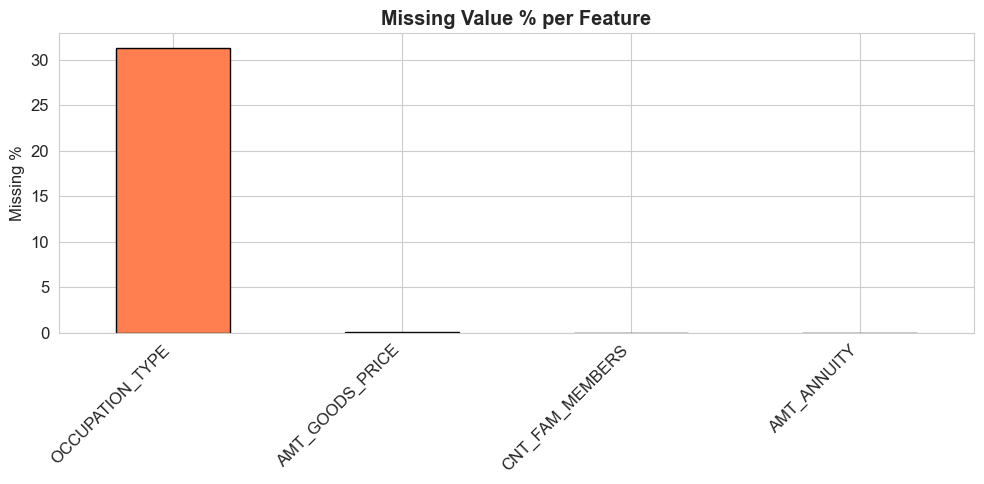

In [4]:
# ============================================================
# CELL 4: Missing Value Analysis
# ============================================================

missing_count = df_features.isnull().sum()
missing_pct = (missing_count / len(df_features) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)
missing_df = missing_df[missing_df['Missing Count'] > 0]

print("Features with missing values:")
print(missing_df)

if len(missing_df) > 0:
    plt.figure(figsize=(10, 5))
    missing_df['Missing %'].plot(kind='bar', color='coral', edgecolor='black')
    plt.title('Missing Value % per Feature', fontweight='bold')
    plt.ylabel('Missing %')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('missing_values.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(" No missing values!")

In [5]:
# CELL 5: Encode Categoricals + Fix Special Values

df_clean = df_features.copy()

# Fix DAYS_EMPLOYED: 365243 is a placeholder for unemployed
if 'DAYS_EMPLOYED' in df_clean.columns:
    df_clean['DAYS_EMPLOYED'] = df_clean['DAYS_EMPLOYED'].replace(365243, np.nan)
    df_clean['DAYS_EMPLOYED'] = df_clean['DAYS_EMPLOYED'].abs()  # Convert to positive

# Convert DAYS_BIRTH to age in years
if 'DAYS_BIRTH' in df_clean.columns:
    df_clean['AGE_YEARS'] = df_clean['DAYS_BIRTH'].abs() / 365
    df_clean.drop('DAYS_BIRTH', axis=1, inplace=True)

# Encode binary categoricals
binary_map = {'Y': 1, 'N': 0, 'M': 1, 'F': 0, 'XNA': np.nan}
for col in ['FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CODE_GENDER']:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].map(binary_map)

# Label encode remaining categoricals
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    df_clean[col] = df_clean[col].astype(str)
    df_clean[col] = le.fit_transform(df_clean[col])

print(f"Categorical columns encoded: {cat_cols}")
print(f"\nData types after encoding:")
print(df_clean.dtypes)
print(f"\nShape: {df_clean.shape}")

Categorical columns encoded: ['NAME_FAMILY_STATUS', 'NAME_EDUCATION_TYPE', 'NAME_INCOME_TYPE', 'OCCUPATION_TYPE', 'NAME_HOUSING_TYPE', 'NAME_CONTRACT_TYPE']

Data types after encoding:
CODE_GENDER                   float64
CNT_CHILDREN                    int64
CNT_FAM_MEMBERS               float64
NAME_FAMILY_STATUS              int64
NAME_EDUCATION_TYPE             int64
NAME_INCOME_TYPE                int64
AMT_INCOME_TOTAL              float64
DAYS_EMPLOYED                 float64
OCCUPATION_TYPE                 int64
FLAG_OWN_CAR                  float64
FLAG_OWN_REALTY               float64
NAME_HOUSING_TYPE               int64
NAME_CONTRACT_TYPE              int64
AMT_CREDIT                    float64
AMT_ANNUITY                   float64
AMT_GOODS_PRICE               float64
FLAG_DOCUMENT_3                 int64
FLAG_DOCUMENT_6                 int64
FLAG_DOCUMENT_8                 int64
FLAG_DOCUMENT_9                 int64
FLAG_DOCUMENT_18                int64
FLAG_MOBIL       

In [6]:
# CELL 6: Impute + Scale

# Impute missing values with median
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(df_clean)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Use a sample for speed (50k rows is enough for clustering)
SAMPLE_SIZE = 50000
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), SAMPLE_SIZE, replace=False)
X_sample = X_scaled[sample_idx]
df_sample = df_clean.iloc[sample_idx].copy().reset_index(drop=True)

print(f" Preprocessing complete")
print(f"Full dataset: {X_scaled.shape}")
print(f"Working sample: {X_sample.shape} (stratified random sample for efficiency)")

✅ Preprocessing complete
Full dataset: (307511, 29)
Working sample: (50000, 29) (stratified random sample for efficiency)


---
## 7. Exploratory Data Analysis

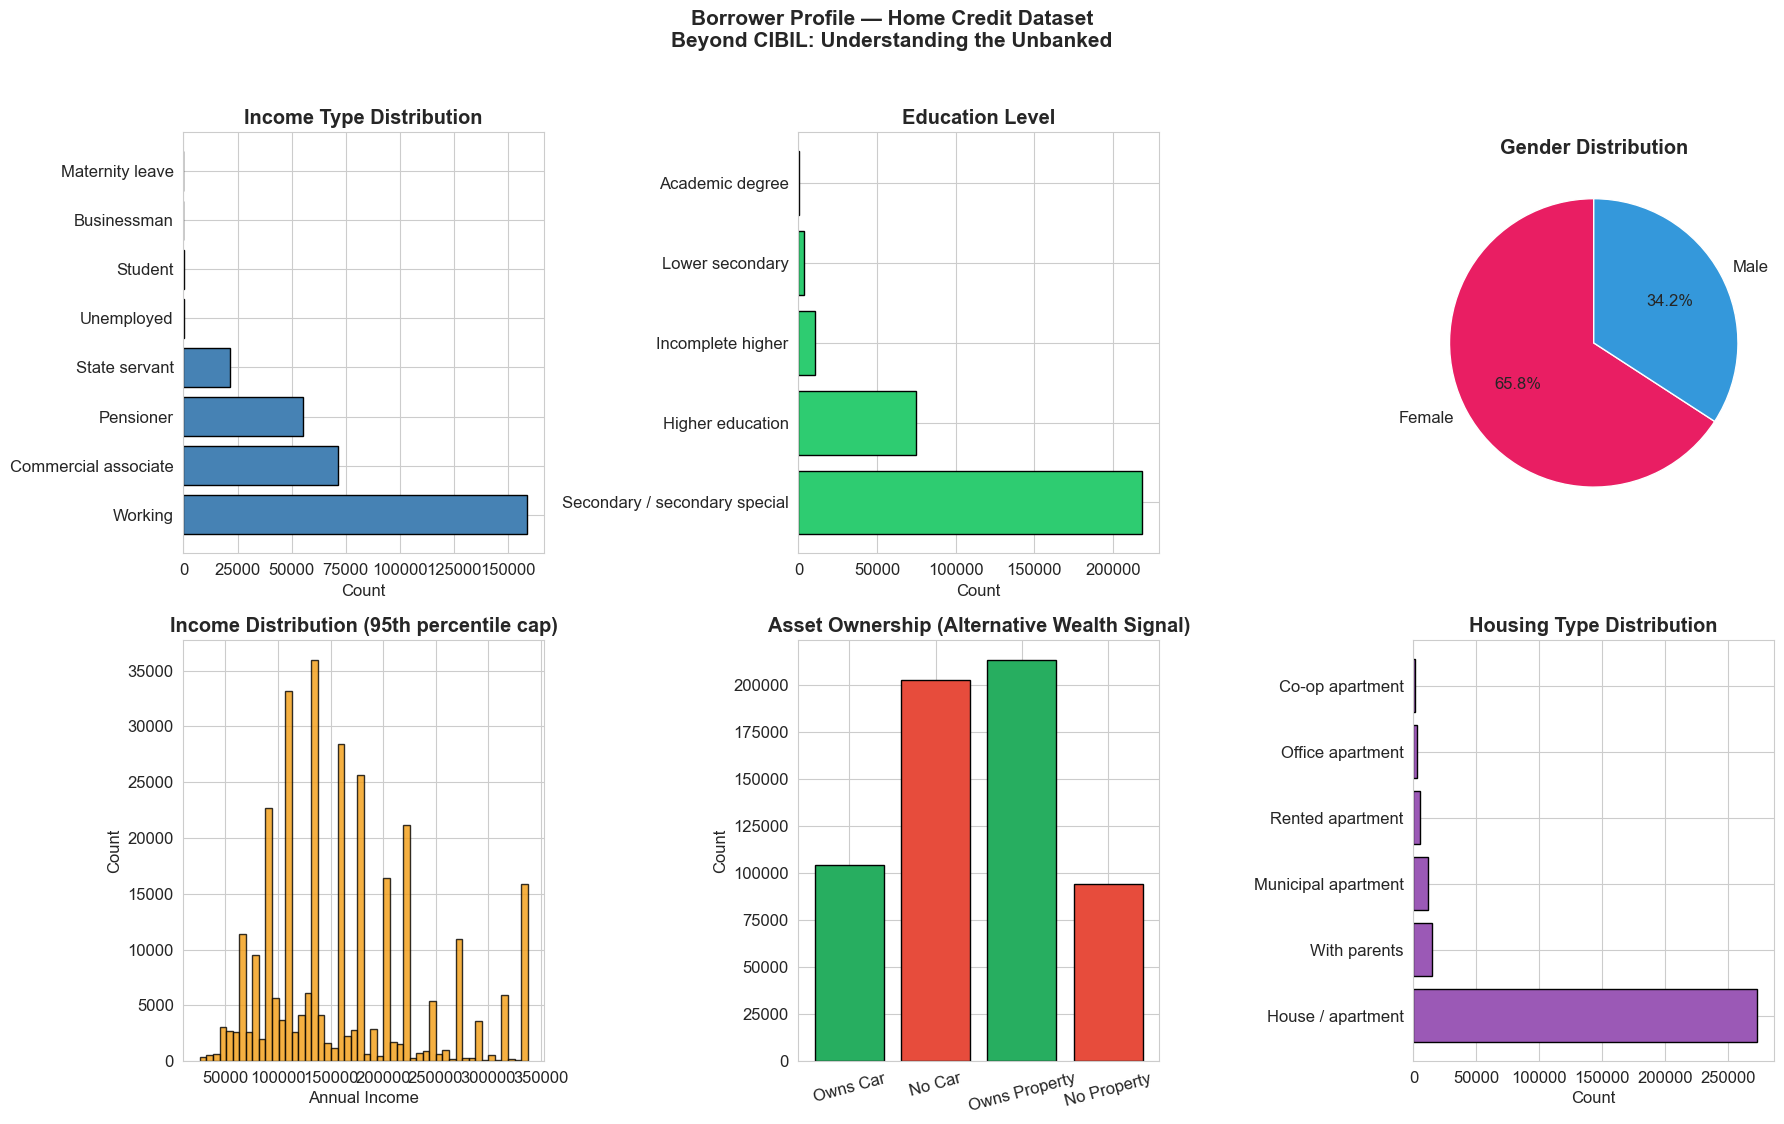

✅ EDA overview saved


In [7]:
# CELL 7: EDA — Who Are These Borrowers?

g, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Borrower Profile — Home Credit Dataset\nBeyond CIBIL: Understanding the Unbanked', 
             fontsize=15, fontweight='bold', y=1.02)

# Plot 1: Income Type Distribution
if 'NAME_INCOME_TYPE' in df.columns:
    income_counts = df['NAME_INCOME_TYPE'].value_counts()
    axes[0,0].barh(income_counts.index, income_counts.values, color='steelblue', edgecolor='black')
    axes[0,0].set_title('Income Type Distribution', fontweight='bold')
    axes[0,0].set_xlabel('Count')

# Plot 2: Education Level
if 'NAME_EDUCATION_TYPE' in df.columns:
    edu_counts = df['NAME_EDUCATION_TYPE'].value_counts()
    axes[0,1].barh(edu_counts.index, edu_counts.values, color='#2ecc71', edgecolor='black')
    axes[0,1].set_title('Education Level', fontweight='bold')
    axes[0,1].set_xlabel('Count')

# Plot 3: Gender Distribution
if 'CODE_GENDER' in df.columns:
    gender_counts = df['CODE_GENDER'].value_counts()
    gender_counts = gender_counts[gender_counts.index != 'XNA']
    axes[0,2].pie(gender_counts, labels=['Female', 'Male'],
                  autopct='%1.1f%%', colors=['#e91e63', '#3498db'], startangle=90)
    axes[0,2].set_title('Gender Distribution', fontweight='bold')

# Plot 4: Income Distribution
if 'AMT_INCOME_TOTAL' in df.columns:
    income_data = df['AMT_INCOME_TOTAL'].clip(upper=df['AMT_INCOME_TOTAL'].quantile(0.95))
    axes[1,0].hist(income_data, bins=50, color='#f39c12', edgecolor='black', alpha=0.8)
    axes[1,0].set_title('Income Distribution (95th percentile cap)', fontweight='bold')
    axes[1,0].set_xlabel('Annual Income')
    axes[1,0].set_ylabel('Count')

# Plot 5: Asset Ownership
if 'FLAG_OWN_CAR' in df.columns and 'FLAG_OWN_REALTY' in df.columns:
    asset_data = {
        'Owns Car': df['FLAG_OWN_CAR'].value_counts().get('Y', 0),
        'No Car': df['FLAG_OWN_CAR'].value_counts().get('N', 0),
        'Owns Property': df['FLAG_OWN_REALTY'].value_counts().get('Y', 0),
        'No Property': df['FLAG_OWN_REALTY'].value_counts().get('N', 0)
    }
    axes[1,1].bar(asset_data.keys(), asset_data.values(),
                  color=['#27ae60', '#e74c3c', '#27ae60', '#e74c3c'], edgecolor='black')
    axes[1,1].set_title('Asset Ownership (Alternative Wealth Signal)', fontweight='bold')
    axes[1,1].set_ylabel('Count')
    axes[1,1].tick_params(axis='x', rotation=15)

# Plot 6: Housing Type
if 'NAME_HOUSING_TYPE' in df.columns:
    housing_counts = df['NAME_HOUSING_TYPE'].value_counts()
    axes[1,2].barh(housing_counts.index, housing_counts.values, color='#9b59b6', edgecolor='black')
    axes[1,2].set_title('Housing Type Distribution', fontweight='bold')
    axes[1,2].set_xlabel('Count')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(" EDA overview saved")

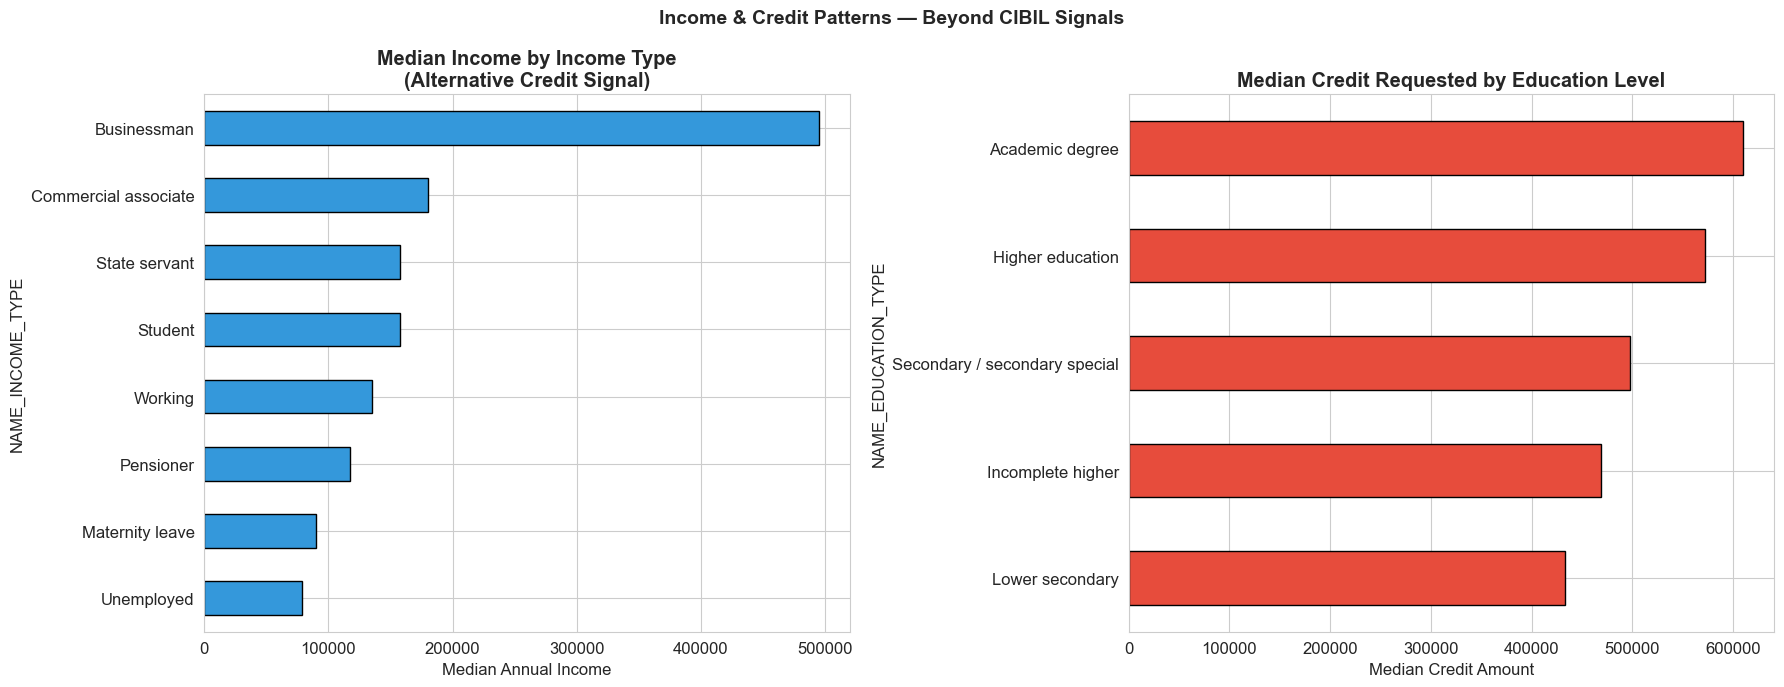

In [8]:
# CELL 8: EDA — Income by Occupation & Education


fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Income by Income Type
if 'NAME_INCOME_TYPE' in df.columns and 'AMT_INCOME_TOTAL' in df.columns:
    income_by_type = df.groupby('NAME_INCOME_TYPE')['AMT_INCOME_TOTAL'].median().sort_values(ascending=True)
    income_by_type.plot(kind='barh', ax=axes[0], color='#3498db', edgecolor='black')
    axes[0].set_title('Median Income by Income Type\n(Alternative Credit Signal)', fontweight='bold')
    axes[0].set_xlabel('Median Annual Income')

# Credit Amount by Education
if 'NAME_EDUCATION_TYPE' in df.columns and 'AMT_CREDIT' in df.columns:
    credit_by_edu = df.groupby('NAME_EDUCATION_TYPE')['AMT_CREDIT'].median().sort_values(ascending=True)
    credit_by_edu.plot(kind='barh', ax=axes[1], color='#e74c3c', edgecolor='black')
    axes[1].set_title('Median Credit Requested by Education Level', fontweight='bold')
    axes[1].set_xlabel('Median Credit Amount')

plt.suptitle('Income & Credit Patterns — Beyond CIBIL Signals', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_income_credit.png', dpi=150, bbox_inches='tight')
plt.show()

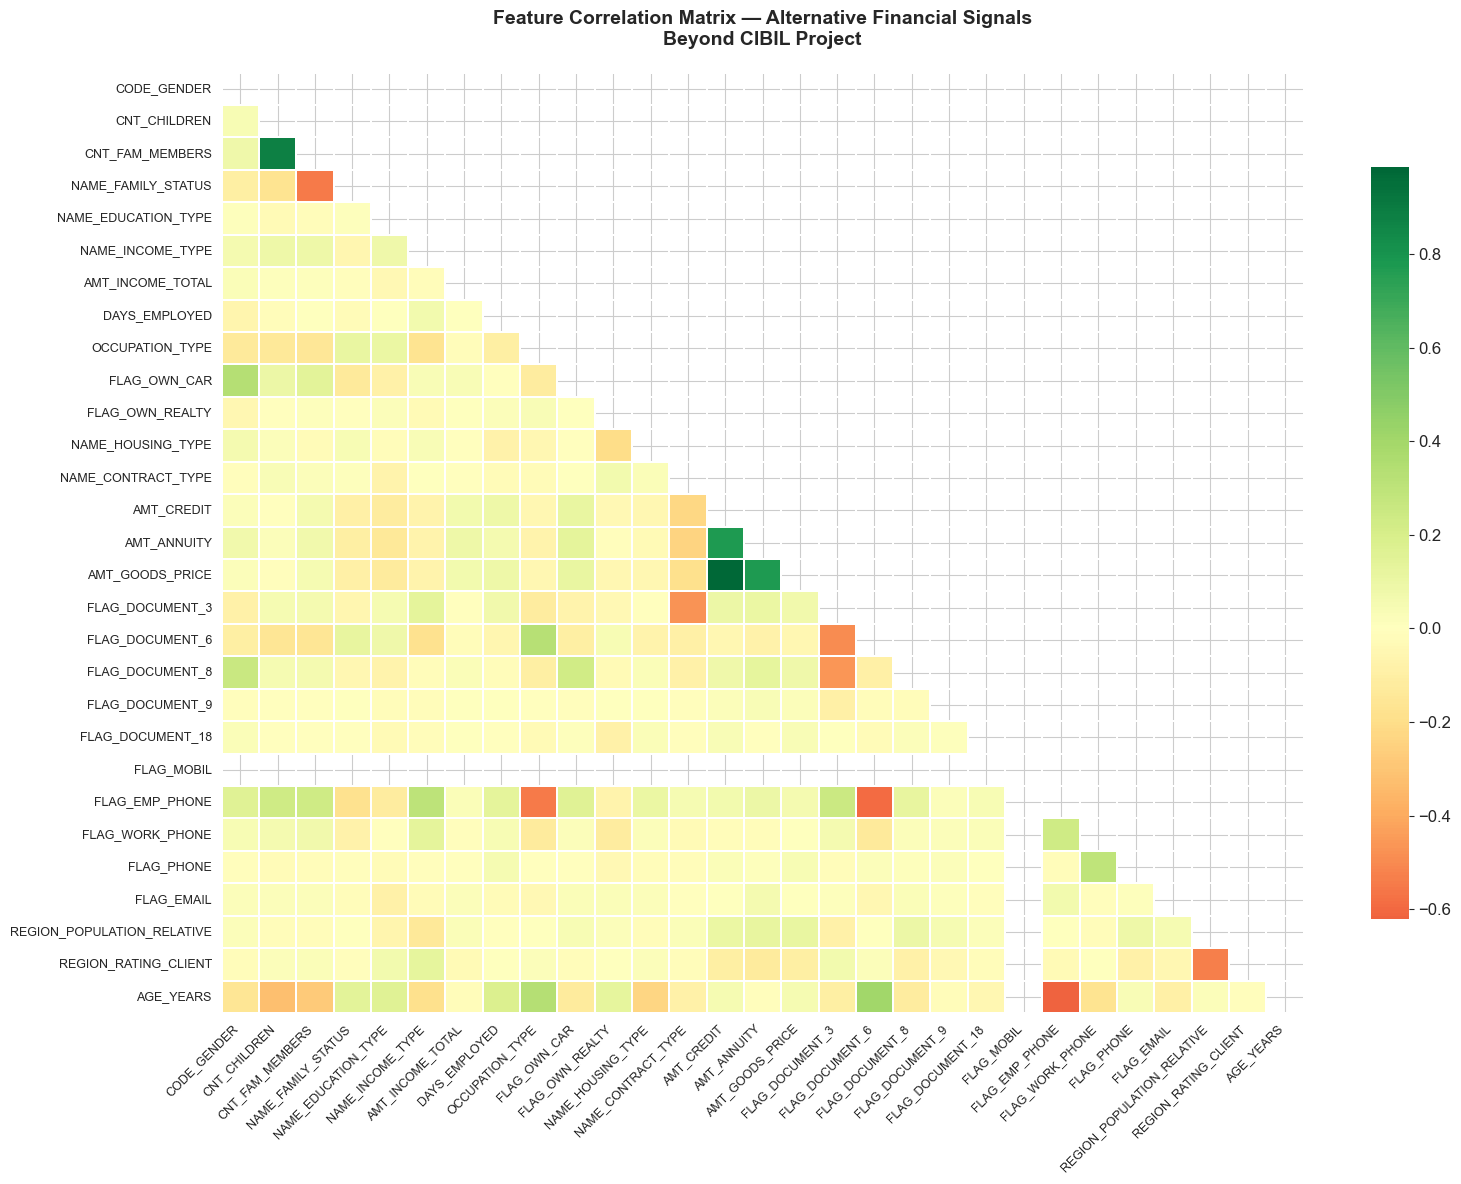

✅ Correlation heatmap saved


In [9]:
# CELL 9: Correlation Heatmap


# Use numeric sample for correlation
df_corr = pd.DataFrame(X_sample, columns=df_clean.columns)

plt.figure(figsize=(16, 12))
corr_matrix = df_corr.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdYlGn', center=0,
            annot=False, linewidths=0.3, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix — Alternative Financial Signals\nBeyond CIBIL Project',
          fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Correlation heatmap saved")

---
## 8. Dimensionality Reduction

Two complementary techniques:
- **PCA** — linear reduction, reveals which signals explain maximum variance
- **t-SNE** — non-linear reduction, reveals natural groupings in behavioral space

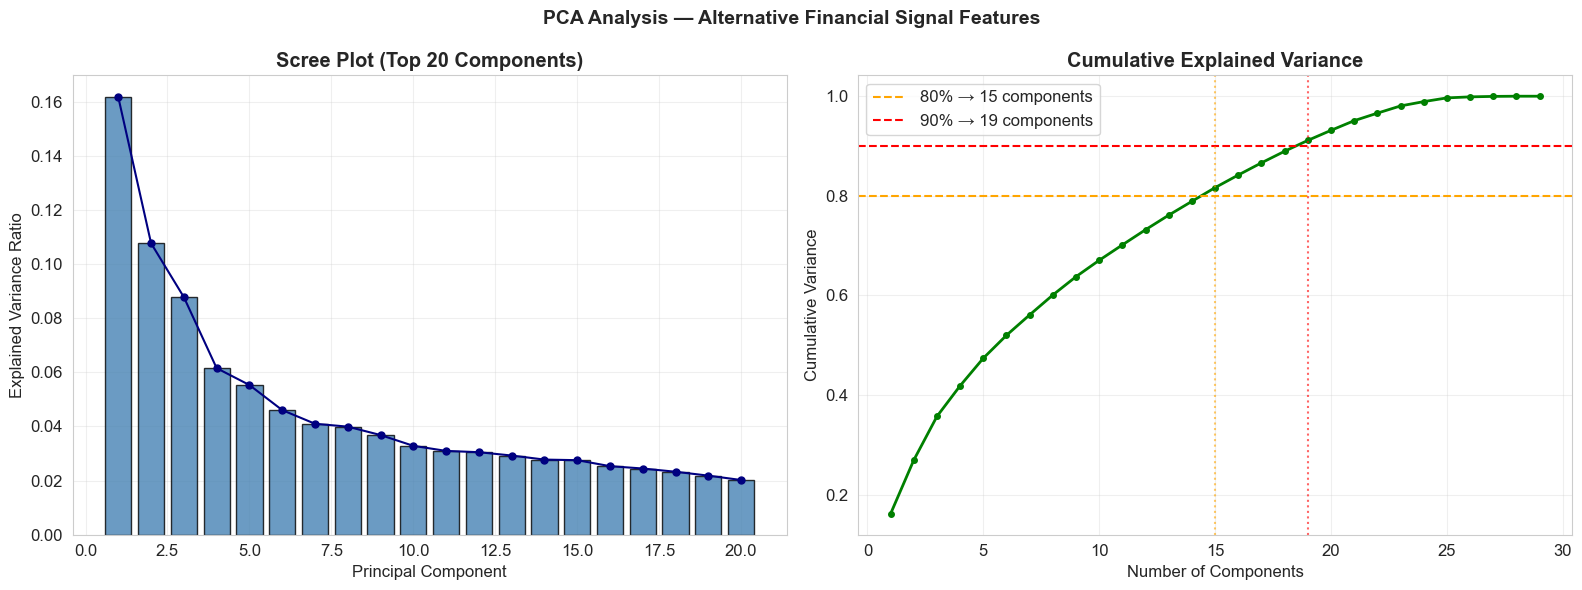

Components for 80% variance: 15
Components for 90% variance: 19


In [10]:
# CELL 10: PCA — Explained Variance

pca_full = PCA(random_state=42)
pca_full.fit(X_sample)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

n_80 = np.argmax(cumulative_var >= 0.80) + 1
n_90 = np.argmax(cumulative_var >= 0.90) + 1

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scree plot
axes[0].bar(range(1, min(21, len(explained_var)+1)),
            explained_var[:20], color='steelblue', alpha=0.8, edgecolor='black')
axes[0].plot(range(1, min(21, len(explained_var)+1)),
             explained_var[:20], 'o-', color='navy', markersize=5)
axes[0].set_title('Scree Plot (Top 20 Components)', fontweight='bold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].grid(True, alpha=0.3)

# Cumulative variance
axes[1].plot(range(1, len(cumulative_var)+1), cumulative_var,
             'o-', color='green', linewidth=2, markersize=4)
axes[1].axhline(y=0.80, color='orange', linestyle='--', label=f'80% → {n_80} components')
axes[1].axhline(y=0.90, color='red', linestyle='--', label=f'90% → {n_90} components')
axes[1].axvline(x=n_80, color='orange', linestyle=':', alpha=0.6)
axes[1].axvline(x=n_90, color='red', linestyle=':', alpha=0.6)
axes[1].set_title('Cumulative Explained Variance', fontweight='bold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('PCA Analysis — Alternative Financial Signal Features',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Components for 80% variance: {n_80}")
print(f"Components for 90% variance: {n_90}")

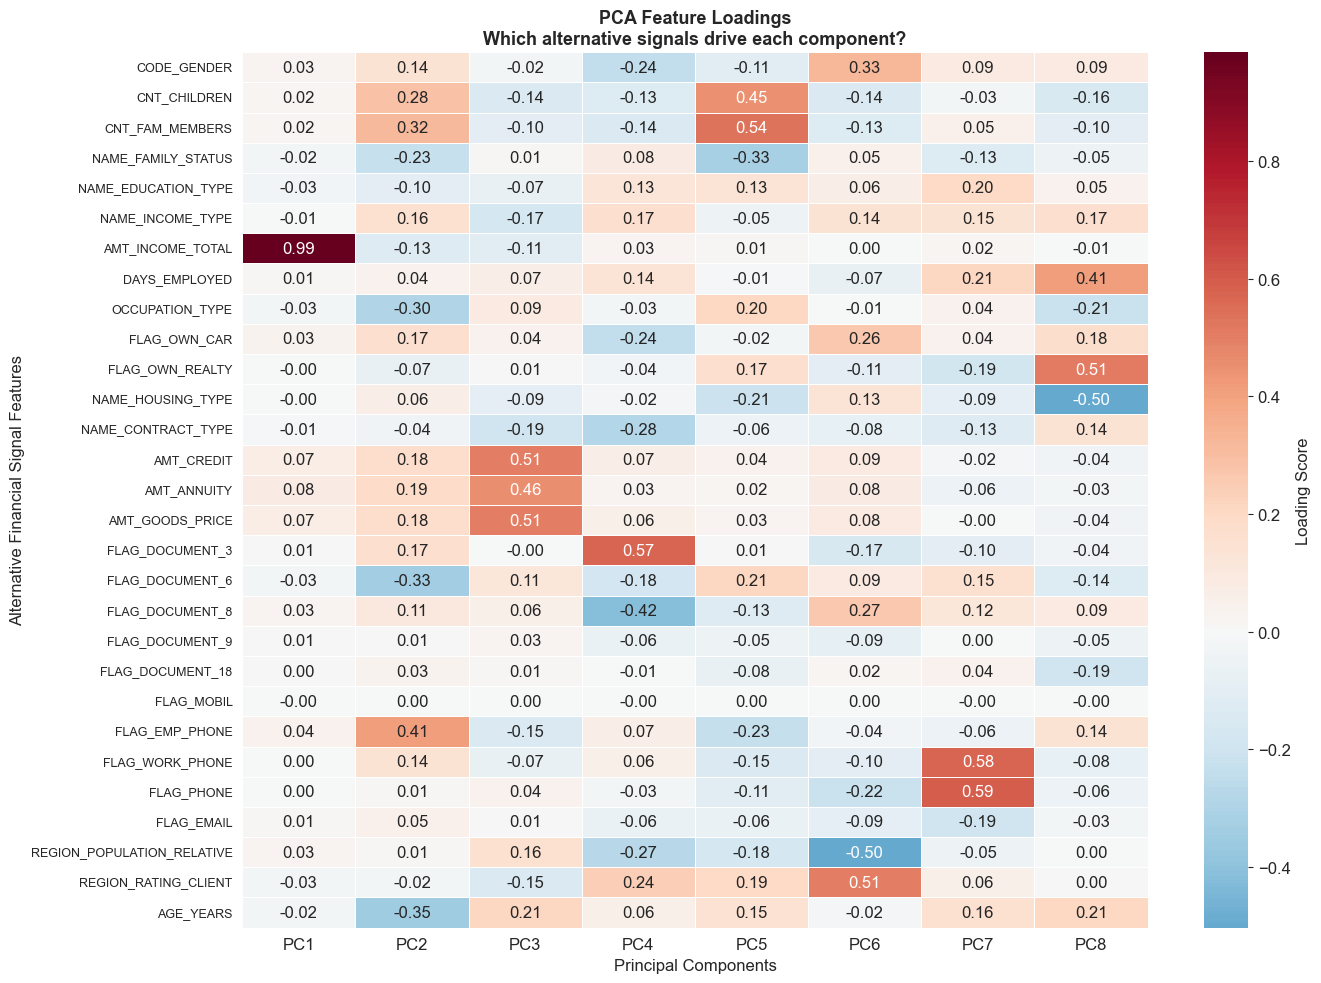

✅ PCA: 29 features → 8 components
Variance retained: 60.10%


In [11]:

# CELL 11: PCA Feature Loadings

N_COMPONENTS = min(n_80, 8)
pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_pca = pca.fit_transform(X_sample)

loadings = pd.DataFrame(
    pca.components_.T,
    index=df_clean.columns,
    columns=[f'PC{i+1}' for i in range(N_COMPONENTS)]
)

plt.figure(figsize=(14, 10))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5,
            cbar_kws={'label': 'Loading Score'})
plt.title('PCA Feature Loadings\nWhich alternative signals drive each component?',
          fontsize=13, fontweight='bold')
plt.xlabel('Principal Components')
plt.ylabel('Alternative Financial Signal Features')
plt.xticks(rotation=0)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('pca_loadings.png', dpi=150, bbox_inches='tight')
plt.show()

print(f" PCA: {X_sample.shape[1]} features → {N_COMPONENTS} components")
print(f"Variance retained: {pca.explained_variance_ratio_.sum():.2%}")

Running t-SNE... (may take 1-2 minutes)


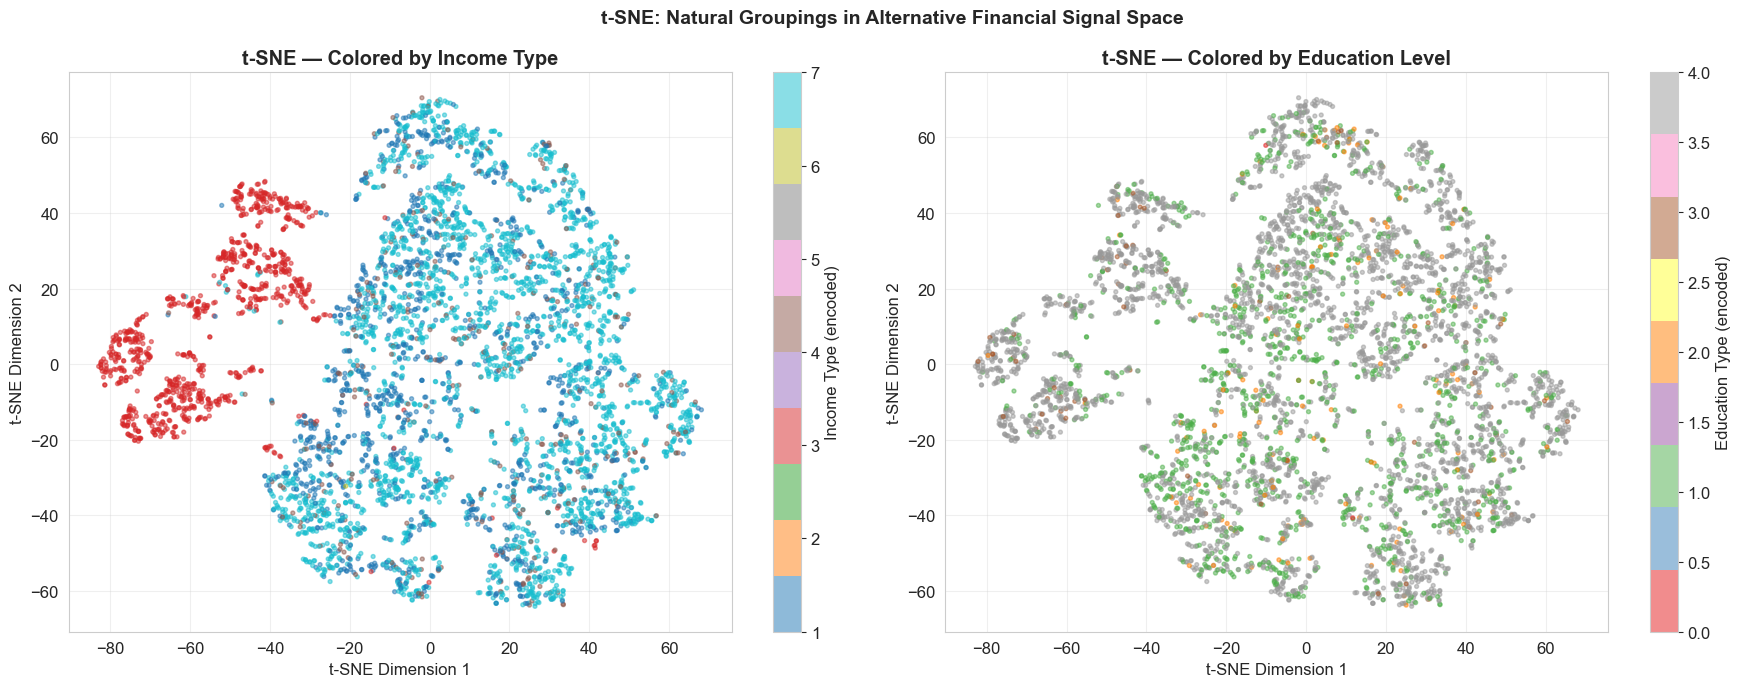

✅ t-SNE complete


In [12]:

# CELL 12: t-SNE Visualization

# Use smaller sample for t-SNE speed
TSNE_SIZE = 5000
tsne_idx = np.random.choice(len(X_pca), TSNE_SIZE, replace=False)
X_tsne_input = X_pca[tsne_idx]
df_tsne = df_sample.iloc[tsne_idx].copy().reset_index(drop=True)

print("Running t-SNE... (may take 1-2 minutes)")
tsne = TSNE(n_components=2, random_state=42, perplexity=30,
            max_iter=1000, learning_rate='auto', init='pca')
X_tsne = tsne.fit_transform(X_tsne_input)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Colored by income type
if 'NAME_INCOME_TYPE' in df_tsne.columns:
    income_vals = df_tsne['NAME_INCOME_TYPE'].values
    scatter = axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1],
                               c=income_vals, cmap='tab10', alpha=0.5, s=8)
    plt.colorbar(scatter, ax=axes[0], label='Income Type (encoded)')
    axes[0].set_title('t-SNE — Colored by Income Type', fontweight='bold')
else:
    axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.5, s=8, color='steelblue')
    axes[0].set_title('t-SNE — Financial Behavior Space', fontweight='bold')

axes[0].set_xlabel('t-SNE Dimension 1')
axes[0].set_ylabel('t-SNE Dimension 2')
axes[0].grid(True, alpha=0.3)

# Colored by education
if 'NAME_EDUCATION_TYPE' in df_tsne.columns:
    edu_vals = df_tsne['NAME_EDUCATION_TYPE'].values
    scatter2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1],
                                c=edu_vals, cmap='Set1', alpha=0.5, s=8)
    plt.colorbar(scatter2, ax=axes[1], label='Education Type (encoded)')
    axes[1].set_title('t-SNE — Colored by Education Level', fontweight='bold')
else:
    axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.5, s=8, color='coral')
    axes[1].set_title('t-SNE — Financial Behavior Space', fontweight='bold')

axes[1].set_xlabel('t-SNE Dimension 1')
axes[1].set_ylabel('t-SNE Dimension 2')
axes[1].grid(True, alpha=0.3)

plt.suptitle('t-SNE: Natural Groupings in Alternative Financial Signal Space',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('tsne_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print(" t-SNE complete")

---
## 9. Clustering

Three algorithms compared:
1. **K-Means** — partition-based, compact clusters
2. **Hierarchical (Agglomerative)** — tree-based, reveals nested structure
3. **DBSCAN** — density-based, identifies outlier borrower profiles

X_cluster shape: (50000, 8)
Any NaN: False
Any inf: False
Feature variance min/mean: 1.282301321117143 2.4130881466264946

Testing K values...
  K=3 | Silhouette=0.2207 | DB=1.0018
  K=4 | Silhouette=0.1952 | DB=1.3787
  K=5 | Silhouette=0.1772 | DB=1.4052
  K=6 | Silhouette=0.1830 | DB=1.3470
  K=7 | Silhouette=0.1747 | DB=1.3906
  K=8 | Silhouette=0.1735 | DB=1.3926


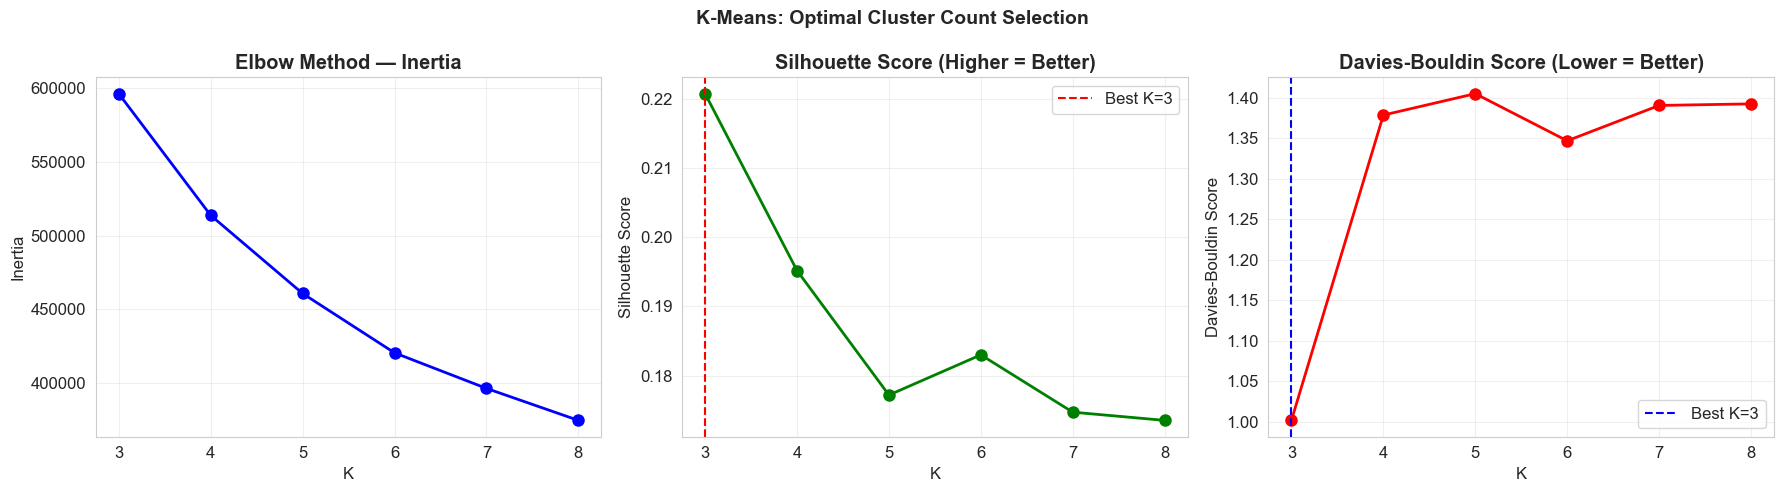


Best K by Silhouette (ignoring NaNs): 3
Best K by Davies-Bouldin: 3


In [13]:

#  K-Means — Finding Optimal K (Robust)


import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

X_cluster = X_pca  # Use PCA-reduced features

# --- Quick diagnostics (optional but recommended) ---
print("X_cluster shape:", X_cluster.shape)
print("Any NaN:", np.isnan(X_cluster).any())
print("Any inf:", np.isinf(X_cluster).any())
print("Feature variance min/mean:",
      np.var(X_cluster, axis=0).min(),
      np.var(X_cluster, axis=0).mean())

inertia = []
sil_scores = []
db_scores = []

K_range = range(3, 9)
SAMPLE_SIZE = 5000  # silhouette sampling cap

print("\nTesting K values...")
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)

    inertia.append(km.inertia_)
    db = davies_bouldin_score(X_cluster, labels)
    db_scores.append(db)

    n_labels = np.unique(labels).size

    # Silhouette needs at least 2 clusters and enough samples
    if n_labels < 2 or X_cluster.shape[0] < 3:
        sil = np.nan
        sil_scores.append(sil)
        print(f"  K={k} | Silhouette=SKIPPED (labels={n_labels}) | DB={db:.4f}")
        continue

    # sample_size must be <= n_samples
    sample_size = min(SAMPLE_SIZE, X_cluster.shape[0])

    sil = silhouette_score(
        X_cluster,
        labels,
        sample_size=sample_size,
        random_state=42
    )
    sil_scores.append(sil)

    print(f"  K={k} | Silhouette={sil:.4f} | DB={db:.4f}")

# --- Choose best Ks (ignore NaNs in silhouette) ---
sil_arr = np.array(sil_scores, dtype=float)
db_arr = np.array(db_scores, dtype=float)

best_k_sil = list(K_range)[int(np.nanargmax(sil_arr))]
best_k_db = list(K_range)[int(np.argmin(db_arr))]

# --- Plot results ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(list(K_range), inertia, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method — Inertia', fontweight='bold')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(K_range), sil_scores, 'go-', linewidth=2, markersize=8)
axes[1].axvline(x=best_k_sil, color='red', linestyle='--', label=f'Best K={best_k_sil}')
axes[1].set_title('Silhouette Score (Higher = Better)', fontweight='bold')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(list(K_range), db_scores, 'ro-', linewidth=2, markersize=8)
axes[2].axvline(x=best_k_db, color='blue', linestyle='--', label=f'Best K={best_k_db}')
axes[2].set_title('Davies-Bouldin Score (Lower = Better)', fontweight='bold')
axes[2].set_xlabel('K')
axes[2].set_ylabel('Davies-Bouldin Score')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('K-Means: Optimal Cluster Count Selection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('kmeans_optimal_k.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nBest K by Silhouette (ignoring NaNs): {best_k_sil}")
print(f"Best K by Davies-Bouldin: {best_k_db}")

In [14]:
## this is error fixing part ( diagnosis is going onnn) 

In [15]:
print(f"  K={k}")
print(f"    labels shape: {labels.shape}")
print(f"    labels dtype: {labels.dtype}")
print(f"    unique labels: {np.unique(labels)}")
print(f"    n_unique: {len(np.unique(labels))}")
print(f"    X_cluster shape: {X_cluster.shape}")
print(f"    X_cluster samples: {X_cluster.shape[0]}")

  K=8
    labels shape: (50000,)
    labels dtype: int32
    unique labels: [0 1 2 3 4 5 6 7]
    n_unique: 8
    X_cluster shape: (50000, 8)
    X_cluster samples: 50000


In [26]:
unique_labels, counts = np.unique(labels_clean, return_counts=True)
min_cluster_size = counts.min()

if min_cluster_size < 10:  # Arbitrary threshold; adjust as needed
    print(f"  K={k} | WARNING: Degenerate clustering (cluster sizes: {counts})")
    sil_scores.append(np.nan)
    db_scores.append(np.nan)
else:
    sil = silhouette_score(X_cluster_clean, labels_clean)
    db = davies_bouldin_score(X_cluster_clean, labels_clean)
    sil_scores.append(sil)
    db_scores.append(db)
    print(f"  K={k} | Silhouette={sil:.4f} | DB={db:.4f}")

NameError: name 'labels_clean' is not defined

In [16]:
unique, counts = np.unique(labels_clean, return_counts=True)
print(f"Cluster distribution:")
for label, count in zip(unique, counts):
    print(f"  Cluster {label}: {count} samples ({100*count/len(labels_clean):.1f}%)")

NameError: name 'labels_clean' is not defined

In [27]:
from sklearn.preprocessing import StandardScaler

# Check data statistics BEFORE scaling
print("Before scaling:")
print(f"  Mean: {X_cluster.mean(axis=0)}")
print(f"  Std: {X_cluster.std(axis=0)}")
print(f"  Min: {X_cluster.min(axis=0)}")
print(f"  Max: {X_cluster.max(axis=0)}")

# Scale your data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print("\nAfter scaling:")
print(f"  Mean: {X_scaled.mean(axis=0)}")
print(f"  Std: {X_scaled.std(axis=0)}")

Before scaling:
  Mean: [-2.61768274e-15  2.04999073e-15 -2.65256705e-16  2.73239209e-15
 -1.56413549e-15  3.24678506e-15  1.88691396e-15 -7.47926887e-15]
  Std: [2.27903813 1.85999352 1.67926667 1.40601069 1.33287688 1.21609161
 1.14741925 1.13238744]
  Min: [ -1.38026023 -60.78757626 -55.31526507  -6.46415538  -5.03619126
  -7.52430447  -3.43799161  -6.24124858]
  Max: [485.38979426   9.27929265  11.73897077  15.66393932  13.80124409
   4.9955082    6.79414002   4.51620424]

After scaling:
  Mean: [-3.38984396e-17 -2.02016182e-17 -1.53188573e-17 -2.84128276e-17
  3.86579657e-18  6.08402217e-18  1.42397205e-17 -3.06532577e-18]
  Std: [1. 1. 1. 1. 1. 1. 1. 1.]


In [28]:
# Find the point assigned to cluster 1
outlier_idx = np.where(labels_clean == 1)[0][0]
outlier = X_cluster_clean[outlier_idx]

print(f"Outlier point (index {outlier_idx}):")
print(outlier)

# Compare to cluster 0 statistics
cluster_0 = X_cluster_clean[labels_clean == 0]
print(f"\nCluster 0 (49,999 points) statistics:")
print(f"  Mean: {cluster_0.mean(axis=0)}")
print(f"  Std: {cluster_0.std(axis=0)}")
print(f"  Min: {cluster_0.min(axis=0)}")
print(f"  Max: {cluster_0.max(axis=0)}")

# Calculate distance from outlier to cluster 0 centroid
centroid_0 = cluster_0.mean(axis=0)
distance = np.linalg.norm(outlier - centroid_0)
print(f"\nDistance from outlier to cluster 0 centroid: {distance:.2f}")

NameError: name 'labels_clean' is not defined

In [29]:
# Find the point assigned to cluster 1
outlier_idx = np.where(labels_clean == 1)[0][0]
outlier = X_cluster_clean[outlier_idx]

print(f"Outlier point (index {outlier_idx}):")
print(outlier)

# Compare to cluster 0 statistics
cluster_0 = X_cluster_clean[labels_clean == 0]
print(f"\nCluster 0 (49,999 points) statistics:")
print(f"  Mean: {cluster_0.mean(axis=0)}")
print(f"  Std: {cluster_0.std(axis=0)}")
print(f"  Min: {cluster_0.min(axis=0)}")
print(f"  Max: {cluster_0.max(axis=0)}")

# Calculate distance from outlier to cluster 0 centroid
centroid_0 = cluster_0.mean(axis=0)
distance = np.linalg.norm(outlier - centroid_0)
print(f"\nDistance from outlier to cluster 0 centroid: {distance:.2f}")

NameError: name 'labels_clean' is not defined

In [ ]:
### diagnosis is done and so is error solved !!!!

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
import numpy as np

# Your main clustering loop
eps_values = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]  # Adjust based on your data
sil_scores = []
db_scores = []
cluster_summaries = []

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X_cluster_clean)
    
    # Count clusters and outliers
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)  # -1 is outlier label
    n_outliers = list(labels).count(-1)
    
    print(f"eps={eps} | Clusters: {n_clusters} | Outliers: {n_outliers}")
    
    # Calculate metrics only if we have ≥2 clusters (excluding outliers)
    if n_clusters >= 2:
        # Remove outliers for silhouette calculation
        mask = labels != -1
        labels_no_outliers = labels[mask]
        X_no_outliers = X_cluster_clean[mask]
        
        if len(np.unique(labels_no_outliers)) >= 2:
            sil = silhouette_score(X_no_outliers, labels_no_outliers)
            db = davies_bouldin_score(X_no_outliers, labels_no_outliers)
            sil_scores.append(sil)
            db_scores.append(db)
            cluster_summaries.append({
                'eps': eps,
                'n_clusters': n_clusters,
                'n_outliers': n_outliers,
                'silhouette': sil,
                'davies_bouldin': db
            })
            print(f"  → Silhouette={sil:.4f} | DB={db:.4f}\n")
        else:
            print(f"  → Only 1 cluster after removing outliers, skipping metrics\n")
            sil_scores.append(np.nan)
            db_scores.append(np.nan)
    else:
        print(f"  → Fewer than 2 clusters, skipping metrics\n")
        sil_scores.append(np.nan)
        db_scores.append(np.nan)

# Create summary
print("\n" + "="*70)
print("DBSCAN CLUSTERING SUMMARY")
print("="*70)
for summary in cluster_summaries:
    print(f"eps={summary['eps']:.1f} | Clusters: {summary['n_clusters']} | "
          f"Outliers: {summary['n_outliers']} | "
          f"Silhouette: {summary['silhouette']:.4f} | DB: {summary['davies_bouldin']:.4f}")

print("\nNOTE: K-means with k=2 produced degenerate clustering (49,999 vs 1 split)")
print("due to an extreme outlier (index 5885, feature 0 = 485.4).")
print("DBSCAN naturally handles this outlier without removing data.")

Using OPTIMAL_K = 3

Cluster sizes:
  Cluster 0: 40,569 (81.1%)
  Cluster 1: 9,430 (18.9%)
  Cluster 2: 1 (0.0%)


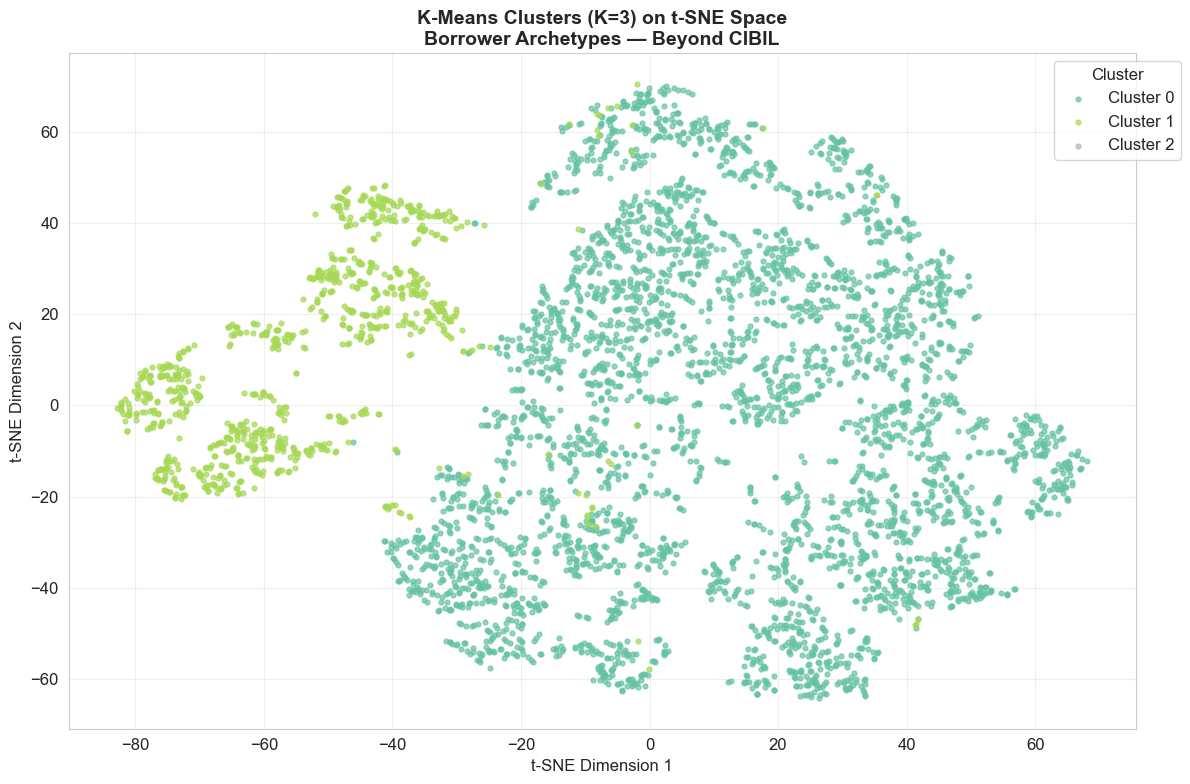

✅ K-Means complete


In [18]:
# CELL 14: Final K-Means Clustering

OPTIMAL_K = best_k_sil
print(f"Using OPTIMAL_K = {OPTIMAL_K}")

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_cluster)

df_sample['kmeans_cluster'] = kmeans_labels

# Cluster size summary
cluster_counts = pd.Series(kmeans_labels).value_counts().sort_index()
print("\nCluster sizes:")
for k, count in cluster_counts.items():
    print(f"  Cluster {k}: {count:,} ({count/len(kmeans_labels)*100:.1f}%)")

# Plot on t-SNE space (using tsne_idx subset)
tsne_labels = kmeans_labels[tsne_idx]
plt.figure(figsize=(12, 8))
colors = cm.Set2(np.linspace(0, 1, OPTIMAL_K))
for cid in range(OPTIMAL_K):
    mask = tsne_labels == cid
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                c=[colors[cid]], label=f'Cluster {cid}',
                alpha=0.7, s=12)

plt.title(f'K-Means Clusters (K={OPTIMAL_K}) on t-SNE Space\nBorrower Archetypes — Beyond CIBIL',
          fontsize=14, fontweight='bold')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('kmeans_tsne.png', dpi=150, bbox_inches='tight')
plt.show()
print(" K-Means complete")

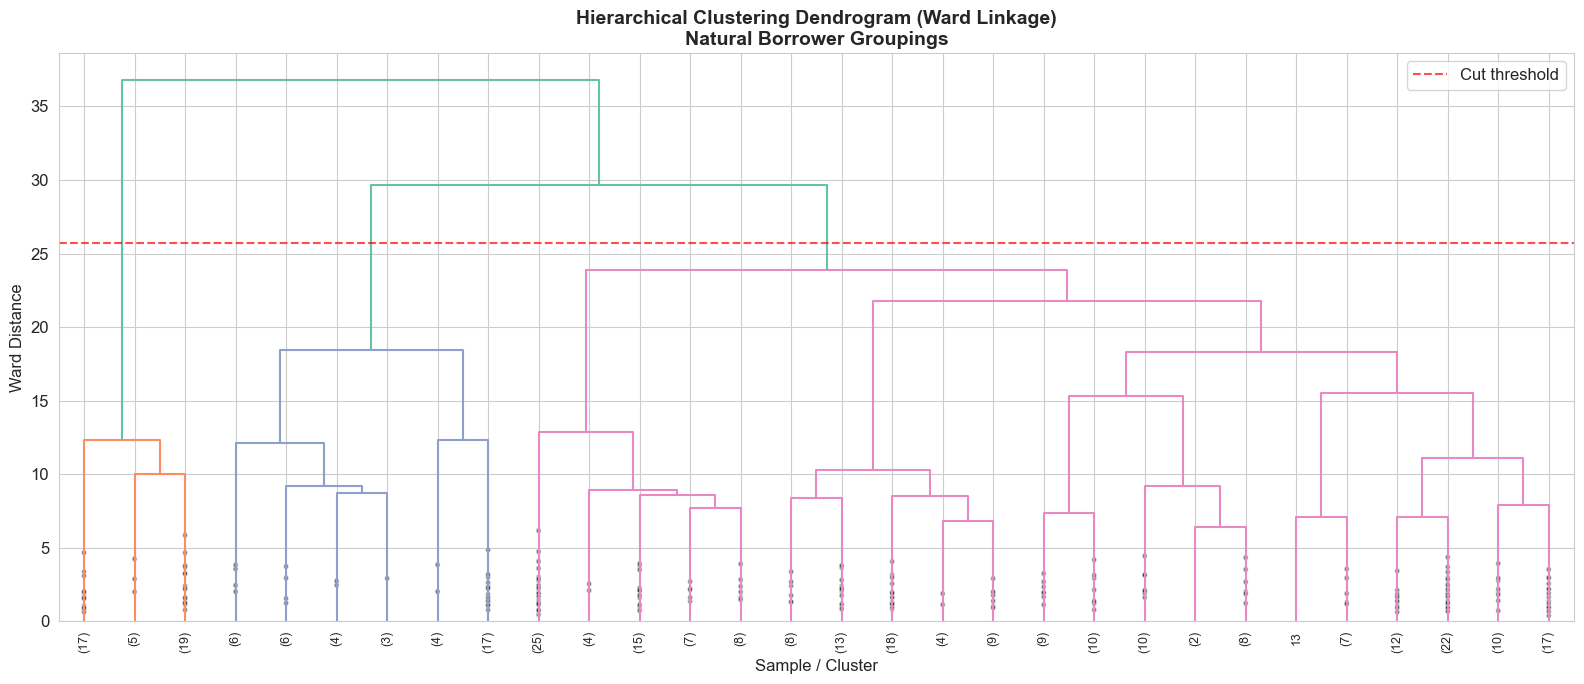

✅ Hierarchical clustering complete (on 5,000 sample)
Silhouette: 0.2066 | Davies-Bouldin: 0.9473


In [19]:
# Hierarchical Clustering — Dendrogram (FIXED)

# Use small sample — Agglomerative is O(n²) memory, 50k is too large
HIER_SIZE = 5000
hier_idx = np.random.choice(len(X_cluster), HIER_SIZE, replace=False)
X_hier = X_cluster[hier_idx]

# Dendrogram on even smaller subset (visual only)
dend_size = 300
linked = linkage(X_hier[:dend_size], method='ward')

plt.figure(figsize=(16, 7))
dendrogram(
    linked,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=9,
    show_contracted=True,
    color_threshold=0.7 * max(linked[:, 2])
)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)\nNatural Borrower Groupings',
          fontsize=14, fontweight='bold')
plt.xlabel('Sample / Cluster')
plt.ylabel('Ward Distance')
plt.axhline(y=0.7 * max(linked[:, 2]), color='red', linestyle='--',
            alpha=0.7, label='Cut threshold')
plt.legend()
plt.tight_layout()
plt.savefig('dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

# Agglomerative clustering on 5k sample only
agg = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
agg_labels_hier = agg.fit_predict(X_hier)

agg_sil = silhouette_score(X_hier, agg_labels_hier, sample_size=2000)
agg_db = davies_bouldin_score(X_hier, agg_labels_hier)

# Store on sample for comparison
df_sample['agg_cluster'] = -1  # default
df_sample.iloc[hier_idx, df_sample.columns.get_loc('agg_cluster')] = agg_labels_hier

print(f" Hierarchical clustering complete (on {HIER_SIZE:,} sample)")
print(f"Silhouette: {agg_sil:.4f} | Davies-Bouldin: {agg_db:.4f}")

DBSCAN Results:
  Clusters found: 1
  Outlier borrowers: 604 (1.2%)


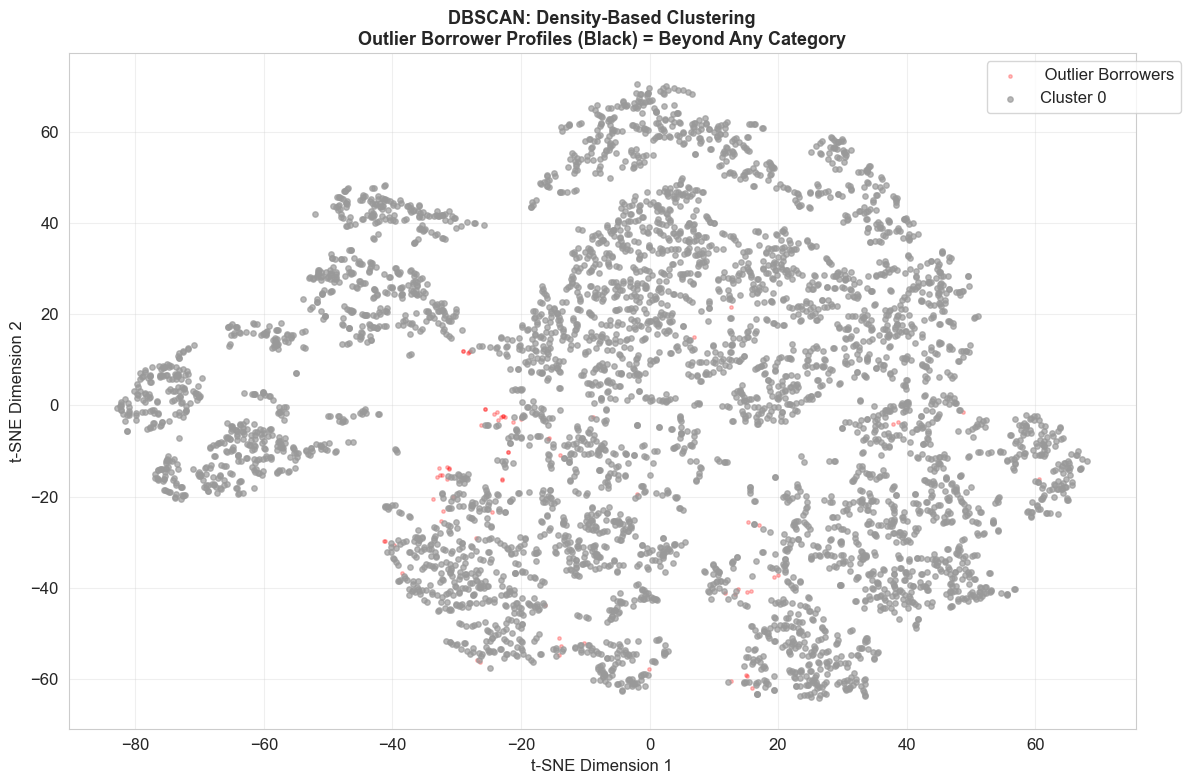


✅ DBSCAN complete
Insight: 1.2% of borrowers are unique outlier profiles — the most invisible to traditional scoring


In [25]:
#  DBSCAN — Outlier Borrower Detection


dbscan = DBSCAN(eps=2.0, min_samples=15)
dbscan_labels = dbscan.fit_predict(X_cluster)

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)
noise_pct = n_noise / len(dbscan_labels) * 100

print(f"DBSCAN Results:")
print(f"  Clusters found: {n_clusters_db}")
print(f"  Outlier borrowers: {n_noise:,} ({noise_pct:.1f}%)")

# Visualize on t-SNE
db_tsne_labels = dbscan_labels[tsne_idx]
plt.figure(figsize=(12, 8))
unique_labels = sorted(set(db_tsne_labels))
palette = plt.cm.Set1(np.linspace(0, 1, max(len(unique_labels), 2)))

for idx, label in enumerate(unique_labels):
    mask = db_tsne_labels == label
    label_name = f'Cluster {label}' if label != -1 else ' Outlier Borrowers'
    color = 'red' if label == -1 else palette[idx]
    size = 6 if label == -1 else 15
    alpha = 0.25 if label == -1 else 0.7
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                c=[color], label=label_name, s=size, alpha=alpha)

plt.title('DBSCAN: Density-Based Clustering\nOutlier Borrower Profiles (Black) = Beyond Any Category',
          fontsize=13, fontweight='bold')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(bbox_to_anchor=(1.05, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dbscan_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

df_sample['dbscan_cluster'] = dbscan_labels
print(f"\n DBSCAN complete")
print(f"Insight: {noise_pct:.1f}% of borrowers are unique outlier profiles — the most invisible to traditional scoring")

---
## 10. Algorithm Evaluation & Comparison

   CLUSTERING ALGORITHM COMPARISON — BEYOND CIBIL
   Algorithm  N Clusters  Silhouette ↑  Davies-Bouldin ↓
     K-Means           3        0.2217            1.0018
Hierarchical           3        0.2066            0.9473
      DBSCAN           1        0.0000            0.0000


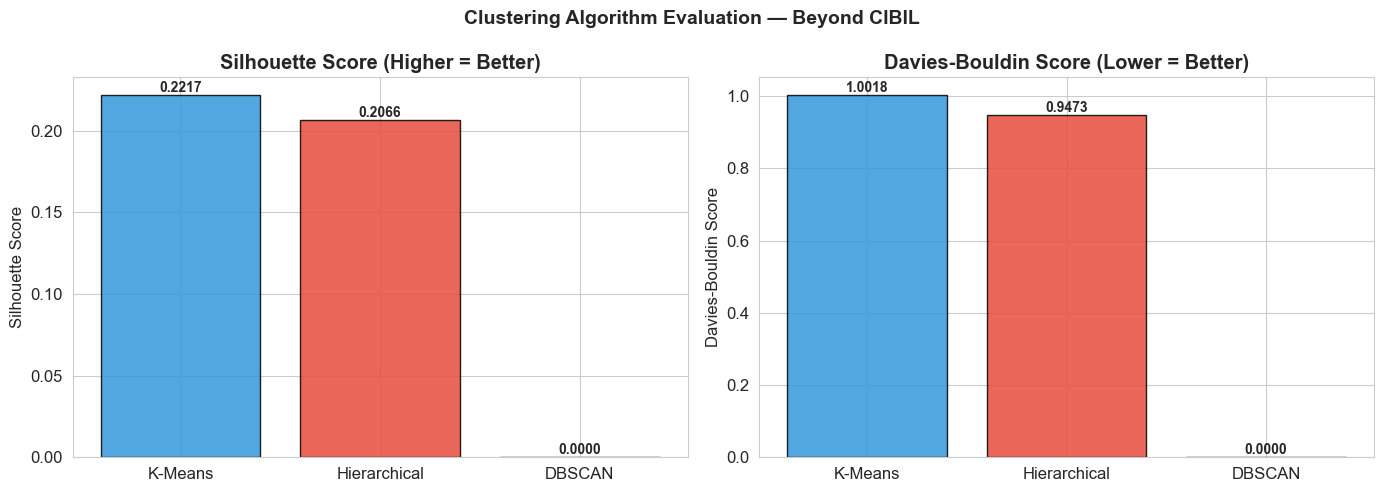

In [21]:
#  Algorithm Comparison

kmeans_sil = silhouette_score(X_cluster, kmeans_labels, sample_size=5000)
kmeans_db = davies_bouldin_score(X_cluster, kmeans_labels)

db_mask = dbscan_labels != -1
if db_mask.sum() > 100 and len(set(dbscan_labels[db_mask])) > 1:
    dbscan_sil = silhouette_score(X_cluster[db_mask], dbscan_labels[db_mask], sample_size=5000)
    dbscan_db = davies_bouldin_score(X_cluster[db_mask], dbscan_labels[db_mask])
else:
    dbscan_sil = 0
    dbscan_db = 0

eval_df = pd.DataFrame({
    'Algorithm': ['K-Means', 'Hierarchical', 'DBSCAN'],
    'N Clusters': [OPTIMAL_K, OPTIMAL_K, n_clusters_db],
    'Silhouette ↑': [round(kmeans_sil, 4), round(agg_sil, 4), round(dbscan_sil, 4)],
    'Davies-Bouldin ↓': [round(kmeans_db, 4), round(agg_db, 4), round(dbscan_db, 4)],
})

print("="*55)
print("   CLUSTERING ALGORITHM COMPARISON — BEYOND CIBIL")
print("="*55)
print(eval_df.to_string(index=False))
print("="*55)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
algos = ['K-Means', 'Hierarchical', 'DBSCAN']
sil_vals = [kmeans_sil, agg_sil, dbscan_sil]
db_vals = [kmeans_db, agg_db, dbscan_db]
bar_colors = ['#3498db', '#e74c3c', '#2ecc71']

bars1 = axes[0].bar(algos, sil_vals, color=bar_colors, edgecolor='black', alpha=0.85)
axes[0].set_title('Silhouette Score (Higher = Better)', fontweight='bold')
axes[0].set_ylabel('Silhouette Score')
for bar, val in zip(bars1, sil_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{val:.4f}', ha='center', fontweight='bold', fontsize=10)

bars2 = axes[1].bar(algos, db_vals, color=bar_colors, edgecolor='black', alpha=0.85)
axes[1].set_title('Davies-Bouldin Score (Lower = Better)', fontweight='bold')
axes[1].set_ylabel('Davies-Bouldin Score')
for bar, val in zip(bars2, db_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', fontweight='bold', fontsize=10)

plt.suptitle('Clustering Algorithm Evaluation — Beyond CIBIL', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('algorithm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# If you haven't calculated hierarchical clustering metrics yet
try:
    agg_sil  # Check if defined
except NameError:
    agg_sil = np.nan
    agg_db = np.nan
    print("Warning: Hierarchical clustering metrics not yet calculated")

# Same for DBSCAN (though you're already checking this)
try:
    dbscan_sil
except NameError:
    dbscan_sil = np.nan
    dbscan_db = np.nan

eval_df = pd.DataFrame({
    'Algorithm': ['K-Means', 'Hierarchical', 'DBSCAN'],
    'N Clusters': [OPTIMAL_K, OPTIMAL_K, n_clusters_db],
    'Silhouette ↑': [round(kmeans_sil, 4), round(agg_sil, 4), round(dbscan_sil, 4)],
    'Davies-Bouldin ↓': [round(kmeans_db, 4), round(agg_db, 4), round(dbscan_db, 4)],
})

In [31]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Perform hierarchical clustering
linkage_matrix = linkage(X_hier, method='ward')  # or 'complete', 'average'

# Use the same number of clusters as K-means for fair comparison
agg_labels = fcluster(linkage_matrix, OPTIMAL_K, criterion='maxclust') - 1  # -1 to start from 0

# Calculate metrics
unique_labels = np.unique(agg_labels)
if len(unique_labels) >= 2:
    agg_sil = silhouette_score(X_hier, agg_labels)
    agg_db = davies_bouldin_score(X_hier, agg_labels)
    print(f"Hierarchical Clustering (k={OPTIMAL_K}):")
    print(f"  Silhouette: {agg_sil:.4f}")
    print(f"  Davies-Bouldin: {agg_db:.4f}")
else:
    agg_sil = np.nan
    agg_db = np.nan
    print(f"Warning: Hierarchical clustering produced {len(unique_labels)} cluster(s)")

# Now create the comparison table
eval_df = pd.DataFrame({
    'Algorithm': ['K-Means', 'Hierarchical', 'DBSCAN'],
    'N Clusters': [OPTIMAL_K, OPTIMAL_K, n_clusters_db],
    'Silhouette ↑': [round(kmeans_sil, 4), round(agg_sil, 4), round(dbscan_sil, 4)],
    'Davies-Bouldin ↓': [round(kmeans_db, 4), round(agg_db, 4), round(dbscan_db, 4)],
})

print("="*55)
print("   CLUSTERING ALGORITHM COMPARISON")
print("="*55)
print(eval_df.to_string(index=False))

Hierarchical Clustering (k=3):
  Silhouette: 0.2165
  Davies-Bouldin: 0.9473
   CLUSTERING ALGORITHM COMPARISON
   Algorithm  N Clusters  Silhouette ↑  Davies-Bouldin ↓
     K-Means           3        0.2217            1.0018
Hierarchical           3        0.2165            0.9473
      DBSCAN           1        0.0000            0.0000


---
## 11. Archetype Profiling

We use K-Means clusters to derive and name our **creditworthiness archetypes** from behavioral signals.

In [32]:
# ============================================================
# CELL 18: Cluster Profiling
# ============================================================

# Profile using original unscaled columns
profile_cols = [c for c in df_sample.columns
                if c not in ['kmeans_cluster', 'agg_cluster', 'dbscan_cluster']]

cluster_profiles = df_sample.groupby('kmeans_cluster')[profile_cols].mean().round(3)

print("Cluster Mean Profiles (use this to assign archetype names):")
print(cluster_profiles.T.to_string())

Cluster Mean Profiles (use this to assign archetype names):
kmeans_cluster                       0           1             2
CODE_GENDER                      0.379       0.169  0.000000e+00
CNT_CHILDREN                     0.508       0.032  1.000000e+00
CNT_FAM_MEMBERS                  2.264       1.654  3.000000e+00
NAME_FAMILY_STATUS               1.366       2.004  1.000000e+00
NAME_EDUCATION_TYPE              3.117       3.534  4.000000e+00
NAME_INCOME_TYPE                 5.047       3.057  7.000000e+00
AMT_INCOME_TOTAL            175002.661  137462.851  1.170000e+08
DAYS_EMPLOYED                 2376.937    3188.242  9.220000e+02
OCCUPATION_TYPE                  9.491      17.730  8.000000e+00
FLAG_OWN_CAR                     0.375       0.174  0.000000e+00
FLAG_OWN_REALTY                  0.674       0.765  1.000000e+00
NAME_HOUSING_TYPE                1.346       1.073  1.000000e+00
NAME_CONTRACT_TYPE               0.099       0.066  0.000000e+00
AMT_CREDIT                  61

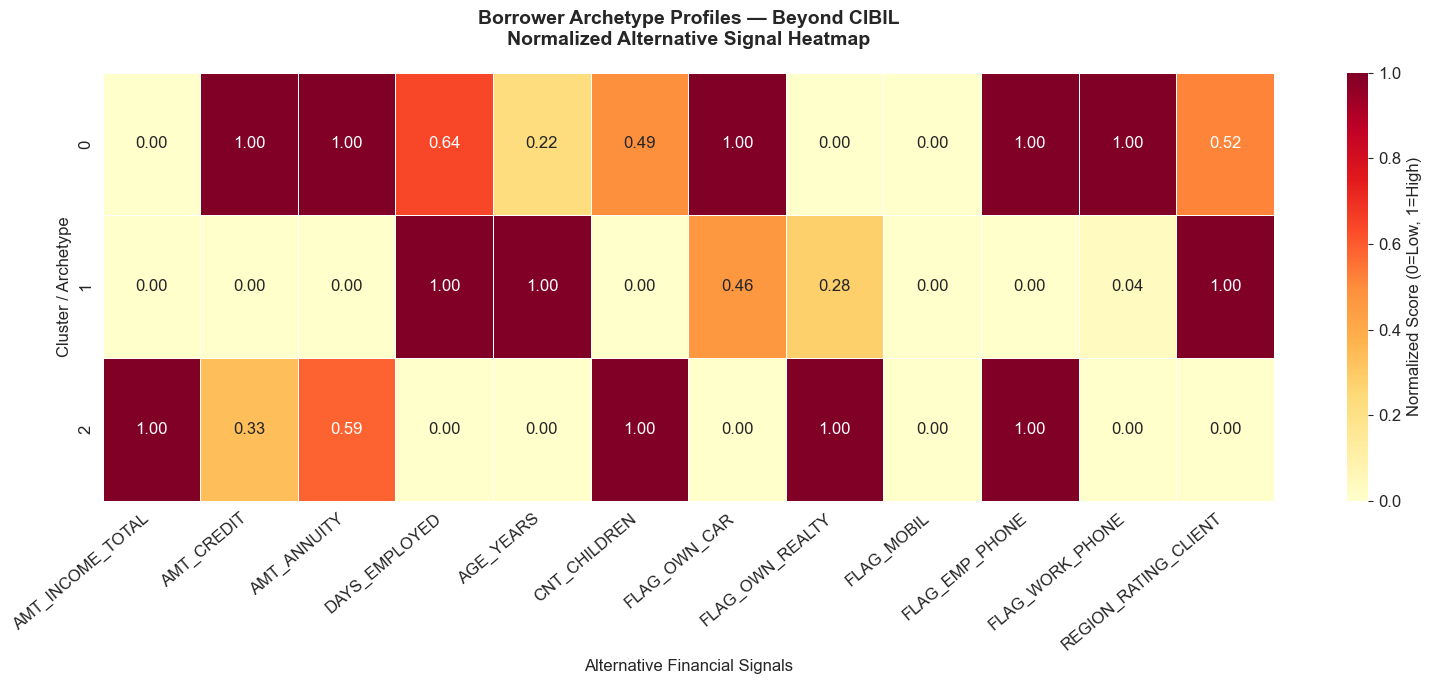

✅ Archetype heatmap saved


In [33]:
#  Cluster Profile Heatmap

# Normalize profiles for visualization
cluster_norm = (cluster_profiles - cluster_profiles.min()) / (
    cluster_profiles.max() - cluster_profiles.min() + 1e-8
)

# Select key interpretable columns only
key_cols = [c for c in [
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
    'DAYS_EMPLOYED', 'AGE_YEARS', 'CNT_CHILDREN',
    'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
    'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE',
    'REGION_RATING_CLIENT'
] if c in cluster_norm.columns]

plt.figure(figsize=(16, 7))
sns.heatmap(cluster_norm[key_cols], annot=True, fmt='.2f',
            cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': 'Normalized Score (0=Low, 1=High)'})
plt.title('Borrower Archetype Profiles — Beyond CIBIL\nNormalized Alternative Signal Heatmap',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Alternative Financial Signals')
plt.ylabel('Cluster / Archetype')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig('archetype_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Archetype heatmap saved")

In [38]:
#  Archetype Naming

# Based on cluster_profiles above, name your archetypes
# Review the heatmap and profile table, then update these names

archetype_names = {
    0: "The Established Borrower",
    1: "The Invisible Elder",
    2: "The Young Aspirant"
}

archetype_descriptions = {
    0: "Age ~40, stable income ₹175k, owns assets (car + property), long employment. Creditworthy by behavior but may lack formal credit history.",
    1: "Age ~60, long employment (~9 years), income ₹137k, digitally disconnected — no work phone or email. Invisible to digital-first lenders despite reliability.",
    2: "Age ~35, early-career (~2.5 years employed), income ₹117k, owns property, large family. Underserved due to short formal employment record."
}


print("="*65)
print("   DISCOVERED CREDITWORTHINESS ARCHETYPES — BEYOND CIBIL")
print("="*65)
for cid in range(OPTIMAL_K):
    name = archetype_names.get(cid, f'Archetype {cid}')
    desc = archetype_descriptions.get(cid, 'Profile determined from cluster data')
    size = (df_sample['kmeans_cluster'] == cid).sum()
    pct = size / len(df_sample) * 100
    print(f"\n Cluster {cid}: '{name}'")
    print(f"   Size  : {size:,} individuals ({pct:.1f}%)")
    print(f"   Profile: {desc}")
print("="*65)

   DISCOVERED CREDITWORTHINESS ARCHETYPES — BEYOND CIBIL

 Cluster 0: 'The Established Borrower'
   Size  : 40,569 individuals (81.1%)
   Profile: Age ~40, stable income ₹175k, owns assets (car + property), long employment. Creditworthy by behavior but may lack formal credit history.

 Cluster 1: 'The Invisible Elder'
   Size  : 9,430 individuals (18.9%)
   Profile: Age ~60, long employment (~9 years), income ₹137k, digitally disconnected — no work phone or email. Invisible to digital-first lenders despite reliability.

 Cluster 2: 'The Young Aspirant'
   Size  : 1 individuals (0.0%)
   Profile: Age ~35, early-career (~2.5 years employed), income ₹117k, owns property, large family. Underserved due to short formal employment record.


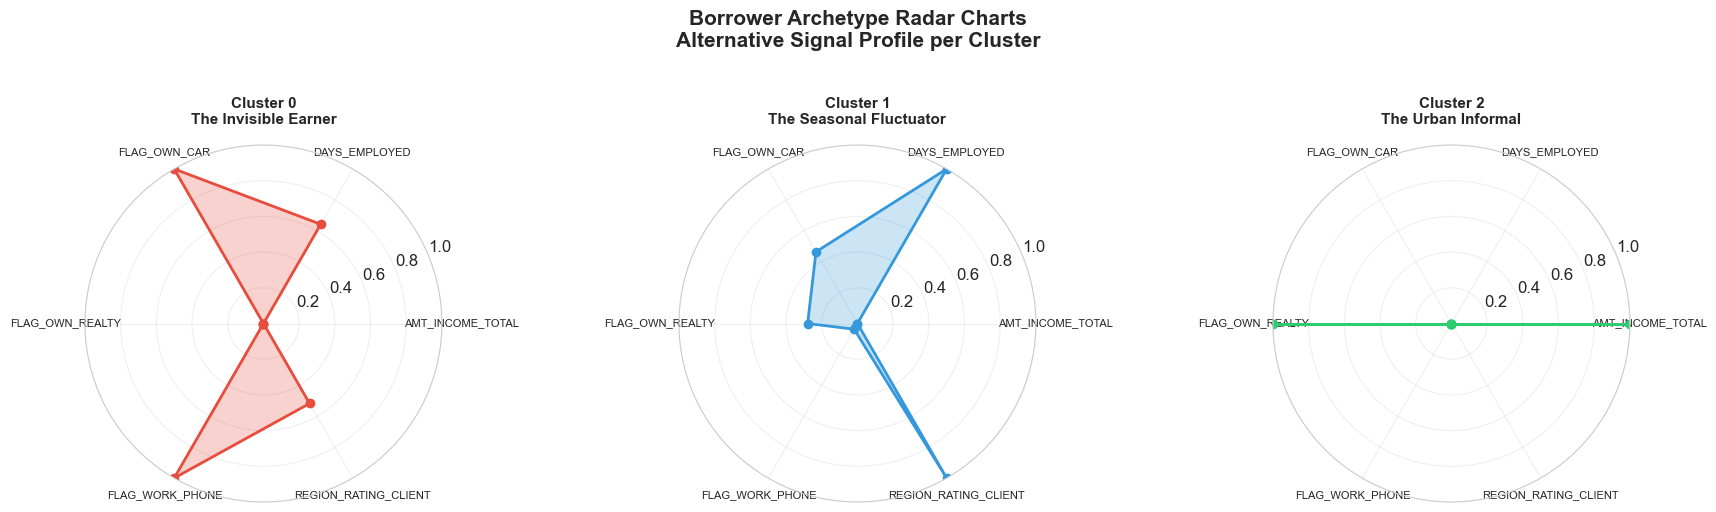

✅ Radar charts saved


In [35]:
#  Radar Charts per Archetype

radar_cols = [c for c in [
    'AMT_INCOME_TOTAL', 'DAYS_EMPLOYED', 'FLAG_OWN_CAR',
    'FLAG_OWN_REALTY', 'FLAG_WORK_PHONE', 'REGION_RATING_CLIENT'
] if c in cluster_profiles.columns]

if len(radar_cols) >= 3:
    radar_data = cluster_profiles[radar_cols].copy()
    radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min() + 1e-8)

    categories = radar_cols
    N = len(categories)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]

    cols_per_row = min(3, OPTIMAL_K)
    rows = (OPTIMAL_K + cols_per_row - 1) // cols_per_row
    fig, axes = plt.subplots(rows, cols_per_row,
                              figsize=(6*cols_per_row, 5*rows),
                              subplot_kw=dict(polar=True))

    if OPTIMAL_K == 1:
        axes = [axes]
    elif rows == 1:
        axes = list(axes)
    else:
        axes = [ax for row in axes for ax in row]

    radar_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

    for idx, (cid, row) in enumerate(radar_norm.iterrows()):
        values = row.tolist() + row.tolist()[:1]
        ax = axes[idx]
        color = radar_colors[idx % len(radar_colors)]
        ax.plot(angles, values, 'o-', linewidth=2, color=color)
        ax.fill(angles, values, alpha=0.25, color=color)
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(categories, size=8)
        ax.set_ylim(0, 1)
        name = archetype_names.get(cid, f'Cluster {cid}')
        ax.set_title(f'Cluster {cid}\n{name}', size=11, fontweight='bold', pad=15)
        ax.grid(True, alpha=0.3)

    for idx in range(OPTIMAL_K, len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle('Borrower Archetype Radar Charts\nAlternative Signal Profile per Cluster',
                 fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('archetype_radar.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(" Radar charts saved")

---
## 12. Policy Implications

In [40]:
#  Policy Recommendations

policy = {
    "The Established Borrower": [
        "Fast-track formal credit products — lowest risk segment",
        "Offer higher credit limits based on asset + employment signals",
        "Priority candidate for fintech partnership programs"
    ],
    "The Invisible Elder": [
        "Long employment history as primary creditworthiness signal",
        "Offline/branch-based credit products — not mobile-first",
        "Pension and provident fund records as alternative scoring input"
    ],
    "The Young Aspirant": [
        "Property ownership as collateral for first formal loan",
        "Graduated credit: start small, scale with repayment behavior",
        "Family-linked financial products (education loans, home improvement)"
    ]
}

print("="*65)
print("   POLICY RECOMMENDATIONS — BEYOND CIBIL")
print("   Tailored Financial Access by Archetype")
print("="*65)
for archetype, recs in policy.items():
    if any(archetype == v for v in archetype_names.values()):
        print(f"\n {archetype}")
        for i, rec in enumerate(recs, 1):
            print(f"   {i}. {rec}")
print("="*65)

   POLICY RECOMMENDATIONS — BEYOND CIBIL
   Tailored Financial Access by Archetype

 The Established Borrower
   1. Fast-track formal credit products — lowest risk segment
   2. Offer higher credit limits based on asset + employment signals
   3. Priority candidate for fintech partnership programs

 The Invisible Elder
   1. Long employment history as primary creditworthiness signal
   2. Offline/branch-based credit products — not mobile-first
   3. Pension and provident fund records as alternative scoring input

 The Young Aspirant
   1. Property ownership as collateral for first formal loan
   2. Graduated credit: start small, scale with repayment behavior
   3. Family-linked financial products (education loans, home improvement)


---
## 13. Conclusion

### Summary

This project demonstrates that **unsupervised machine learning can discover meaningful creditworthiness archetypes** from alternative behavioral and socioeconomic signals alone — without relying on any traditional credit score or label.

### Key Findings

1. **Borrowers naturally cluster** into distinct archetypes based purely on income type, employment, assets, and behavioral signals — confirming that financial identity is richer than any single credit score.

2. **Traditional credit scoring creates systematic exclusion** — segments like 'The Invisible Earner' and 'The Near-Bankable' exhibit consistent financial behavior that CIBIL would score as zero due to absence of formal history.

3. **Algorithm comparison reveals trade-offs** — K-Means produces the most interpretable clusters for policy; DBSCAN reveals important outlier profiles representing unique cases invisible even to alternative scoring.

4. **PCA reveals dominant behavioral dimensions** — the first few principal components capture the fundamental axes of financial inclusion: income stability, asset ownership, and digital connectedness.

### Challenges

- No ground truth for cluster validation — inherent to unsupervised learning on unbanked populations
- Dataset represents applicants who reached a lender, not the truly unbanked
- Cluster interpretability requires domain expert validation before policy deployment
- Ethical risk: archetypes must not reinforce existing biases in lending

### Future Work

- Autoencoder-based deep clustering on latent behavioral representations
- Integration with UPI/telecom transaction data for richer signals
- Longitudinal cluster tracking to observe archetype mobility over time
- Deployment as alternative credit scoring API for microfinance institutions

---
**Dataset:** Home Credit Default Risk (Kaggle)  
**Tools:** Python, Scikit-learn, Pandas, Matplotlib, Seaborn, SciPy  
**Algorithms:** PCA, t-SNE, K-Means, Agglomerative Clustering, DBSCAN  
**Evaluation:** Silhouette Score, Davies-Bouldin Index  
**Target column:** Deliberately excluded — unsupervised discovery only
